<a href="https://colab.research.google.com/github/xjuarezanalytics-commits/TripleTen_Portfolio/blob/main/Sprint_2_Video_Game_Analysis/Video_Game_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Campaña de publicidad 2017

Durante este proyecto se realizará un análisis para identificar los patrones sobre el éxito en los videojuegos basandonos en las reseñas de usuarios y expertos, generos y plataformas.
Este análisis nos permitirá identificar proyectos prometedores y planear campañas publicitarias.

## 1. Librerias y datos.

Revisamos estructura de los datos e información de importancia.

In [15]:
# Importar todas las librerías
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns

In [16]:
# Cargamos archivo
games_df = pd.read_csv('https://raw.githubusercontent.com/xjuarezanalytics-commits/TripleTen_Portfolio/main/Sprint_2_Video_Game_Analysis/games.csv')

In [17]:
# Revisión general.
print (games_df.info())
print ()
print (games_df.head())
print ()

print ("Valores ausentes:")
print (games_df.isnull().sum())
print ()
print (f"Valores duplicados: {games_df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     2

Dentro de este DataFrame nos podemos dar cuenta de varias cosas:

1. Contamos con valores ausentes en las columnas: 'name', 'year_of_realease','critic_score', 'User_Score' y 'Rating'
   
2. Hay algunos tipos de datos que no concuerdan, como 'year_of_release' y 'User_Score'
   
3. No tenemos valores duplicados.

## 2. Preparación de los datos.

En esta sección vamos a realizar los cambios necesarios para que el análisis posterior sea más fácil, como por ejemplo, cambios en los tipos de datos, limpieza de nombres de columnas y estandarización de nombres.

In [18]:
# Remplazar nombres de columnas (minúsculas)
games_df.columns = games_df.columns.str.lower()
print (games_df.info())
print ()

# Normalizamos nombres de plataformas a mayúsculas para facilitar el análisis.
games_df['platform'] = games_df['platform'].str.upper()
print("Columna platform en mayusculas:")
print (games_df['platform'].head())

# Normalizamos nombres de plataformas eliminando espacios extras en los nombres
games_df['platform'] = games_df['platform'].str.strip()
games_df['name'] = games_df['name'].str.strip()
print ()
print (games_df['platform'].head())
print ()
print (games_df['name'].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None

Columna platform en mayusculas:
0    WII
1    NES
2    WII
3    WII
4     GB
Name: platform, dtype: object

0    WII
1    NES
2    WII
3    WII
4     GB
Name: platform, dtype: object

0                  Wii Sports
1           Super Mar

Conversión a tipos de datos correspondientes.  

In [19]:
# Conviertir los datos en los tipos necesarios.

# Columna 'year_of_release'
games_df['year_of_release'] = games_df['year_of_release'].astype('Int64')
print (games_df['year_of_release'].head())
print ()

# Columna 'user_score'
games_df['user_score'] = games_df['user_score'].replace('tbd', np.nan)
games_df['user_score'] = pd.to_numeric(games_df['user_score'])
print (games_df['user_score'].head())
print ()

# Revisión en tipos de datos:
print (games_df.info())

0    2006
1    1985
2    2008
3    2009
4    1996
Name: year_of_release, dtype: Int64

0    8.0
1    NaN
2    8.3
3    8.0
4    NaN
Name: user_score, dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB
None


En estas columnas en donde los tipos de datos fueron modificados (year_of_release y user_score) Los valores 'tbd' fueron modificados a valores NaN puesto que es una puntuación no disponible en ese momento.
Después de la conversión en la columna 'user_score' paso de tener 10,014 valores no-nulos a 7,590 no-nulos, lo que nos confirma que había bastantes valores 'tbd' que acualmente son valores NaN.

### 2.1 Tratar con valores ausentes.

En esta sección trataremos valores ausentes de las columnas 'year_of_release', 'name', 'genre', critic_score', 'user_score' y 'rating'.

In [20]:
# Columnas 'name' y 'genre'
games_df.dropna(subset=['name', 'genre'], inplace=True)
print (games_df.isnull().sum())

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64


En este caso, los valores ausentes de estas columnas eran únicamente 2, por lo que fueron elimiadas para facilitar el análsis y hacerlo más limpio.

In [21]:
games_df.dropna(subset= ['year_of_release'], inplace = True)
print (games_df.isnull().sum())

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64


En el caso de los valores nulos dentro de 'year_of_release' después de analizar varias posibilidades sobre como tratar con los datos (como usar mediana o rellenarlos como 'desconocido') al final se optó por eliminar los datos ya que si llenamos los datos con la mediana podriamos errar y distorcionar el análisis.
Se decidió que eliminarlas era lo mejor ya que el año de lanzamiento es fundamental para el análisis temporal. Además de que 269 filas de 16715 es menos del 2% de la información, por lo que su impacto es mínimo.
En el caso de las columnas 'critic_score', 'user_score' y 'rating' se quedaron como valores NaN intencionalmente para hacer el análisis más limpio y evitar que los datos se distorcionen. Se considera que en estas columnas tienen valores ausentes ya que tal vez muchos de los usuarios no suelen calificar los juegos o que muchos de los videjuegos más antiguos no tenían plataformas digitales donde registrar las reseñas.

### 2.2 Calcular ventas totales

In [22]:
# Calculamos las ventas totales para cada uno de los juegos creando una nueva columna.
games_df ['total_sales'] = games_df['na_sales'] + games_df ['eu_sales'] + games_df ['jp_sales'] + games_df ['other_sales']
print (games_df['total_sales'].head())
print (games_df.head())

0    82.54
1    40.24
2    35.52
3    32.77
4    31.38
Name: total_sales, dtype: float64
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      WII             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      WII             2008        Racing     15.68   
3         Wii Sports Resort      WII             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
4      8.89     10.22         1.00           NaN         NaN    NaN  

## 3. Análisis de datos.

Para este análisis revisaremos datos de importancia como la venta de videojuegos por año, su realción entre las diferentes plataformas, plataformas ligeres, generos más rentables, lo que nos ayudará a identificar patrones de compra de los usuarios.

### 3.1 Videojuegos por año.

Analizamos cuantos juegos fueron lanzados en diferentes años.

In [23]:
# Calculamos los juegos por año.
games_per_year = games_df.groupby ('year_of_release')['name'].count().reset_index()
print (games_per_year)

    year_of_release  name
0              1980     9
1              1981    46
2              1982    36
3              1983    17
4              1984    14
5              1985    14
6              1986    21
7              1987    16
8              1988    15
9              1989    17
10             1990    16
11             1991    41
12             1992    43
13             1993    60
14             1994   121
15             1995   219
16             1996   263
17             1997   289
18             1998   379
19             1999   338
20             2000   350
21             2001   482
22             2002   829
23             2003   775
24             2004   762
25             2005   939
26             2006  1006
27             2007  1197
28             2008  1427
29             2009  1426
30             2010  1255
31             2011  1136
32             2012   653
33             2013   544
34             2014   581
35             2015   606
36             2016   502


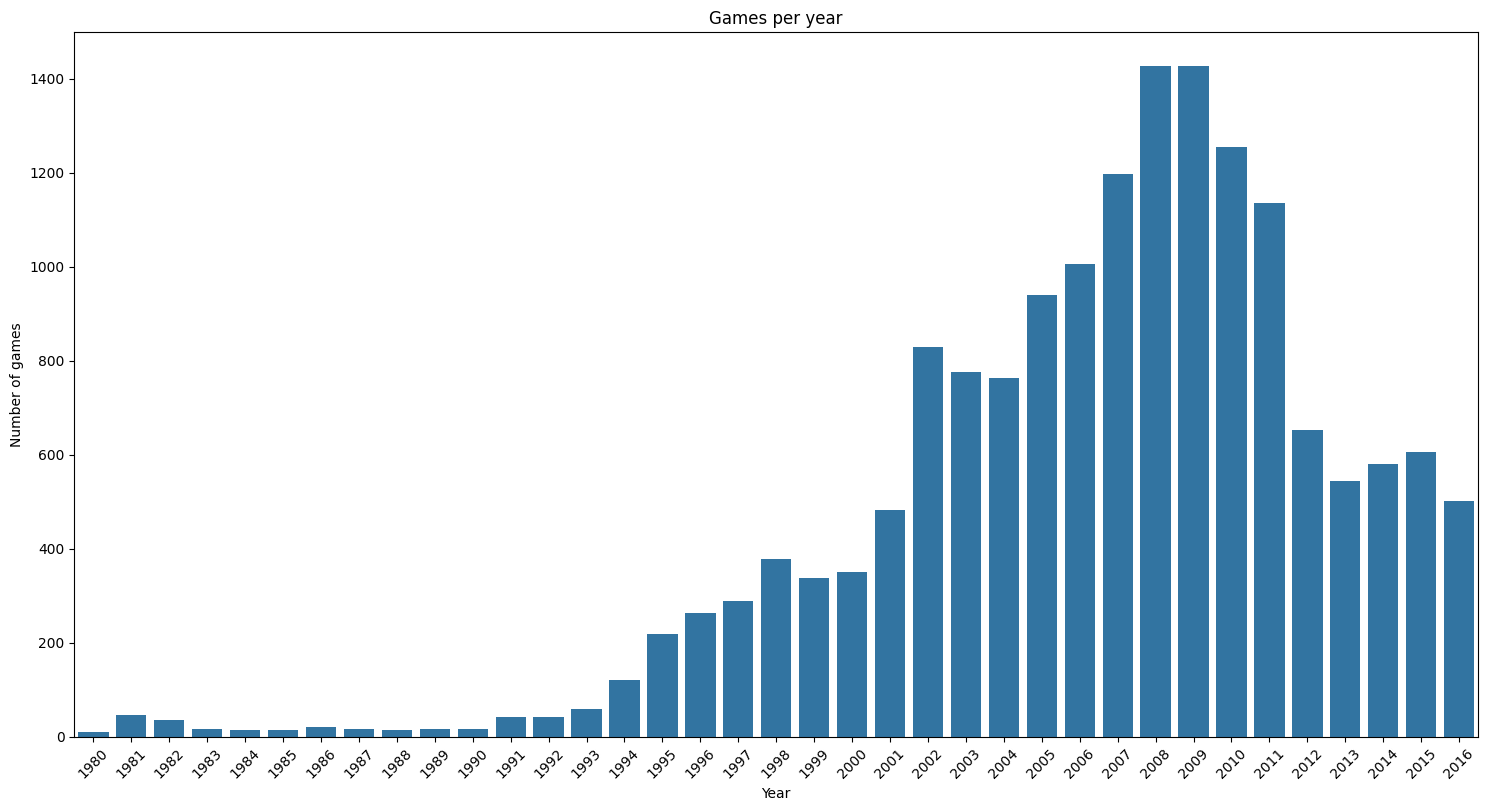

In [24]:
# Graficamos un grafico de barras.

plt.figure(figsize = (15,8))
sns.barplot (data= games_per_year, x='year_of_release', y= 'name')
plt.title('Games per year')
plt.xlabel('Year')
plt.ylabel('Number of games')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

Con este grafico nos podemos dar cuenta que los datos antes de los años 90 realmente son muy pocos, no es hasta 1991 en donde vemos un crecimiento sostenido hata los años 2008 - 2009 donde hay un pico en el lanzamiento de los videojuegos y posteriormente una caida.
Los datos anteriores de 1983 - 1990 son muy escasos y poco representativos.

### 3.2 Ventas en diferentes plataformas.

Ya que la campaña publicitaria del 2017 requiere de los datos más actuales para poder predecir los datos del 2017 únicamente trabajaremos con los datos del 2010 al 2016 ya que una plaforma de videjuegos tiene un tipo de vida estimado de 5 a 7 años. Con este rango de fechas capturamos el ciclo de vida completo de platafomas modernas y usamos datos recientes y relevantes.

In [25]:
# Creamos dataframe filtrado con los años relevantes para el análisis.
filtered_df = games_df[(games_df['year_of_release'] >= 2010) & (games_df['year_of_release'] <= 2016)].sort_values('year_of_release').reset_index()
print (filtered_df.head())

   index                         name platform  year_of_release         genre  \
0     68                 Just Dance 2      WII             2010          Misc   
1     27  Pokemon Black/Pokemon White       DS             2010  Role-Playing   
2   4680          Tom Clancy's HAWX 2      PS3             2010        Action   
3   4669             MLB 10: The Show      PS2             2010        Sports   
4   4664    pro evolution soccer 2011      PS2             2010        Sports   

   na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0      5.80      2.85      0.01         0.78          74.0         7.3   E10+   
1      5.51      3.17      5.65         0.80           NaN         NaN    NaN   
2      0.21      0.12      0.03         0.05          70.0         6.8      T   
3      0.20      0.16      0.00         0.05           NaN         NaN      E   
4      0.04      0.21      0.05         0.11           NaN         6.7      E   

   total_sales  
0        

In [26]:
# Identificamos plataformas con mayores ventas totales.
platforms_wiht_highest_sales = filtered_df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()
print (platforms_wiht_highest_sales )

   platform  total_sales
0       PS3       587.74
1      X360       550.41
2       PS4       314.14
3       3DS       257.81
4       WII       222.97
5      XONE       159.32
6        DS       123.75
7        PC       121.96
8      WIIU        82.19
9       PSP        64.05
10      PSV        53.81
11      PS2         6.09


Realizamos una distribución para comprender mejor que plataformas son más rentables.

   platform  year_of_release  total_sales
0       3DS             2011        63.20
1       3DS             2012        51.36
2       3DS             2013        56.57
3       3DS             2014        43.76
4       3DS             2015        27.78
..      ...              ...          ...
60     X360             2016         1.52
61     XONE             2013        18.96
62     XONE             2014        54.07
63     XONE             2015        60.14
64     XONE             2016        26.15

[65 rows x 3 columns]


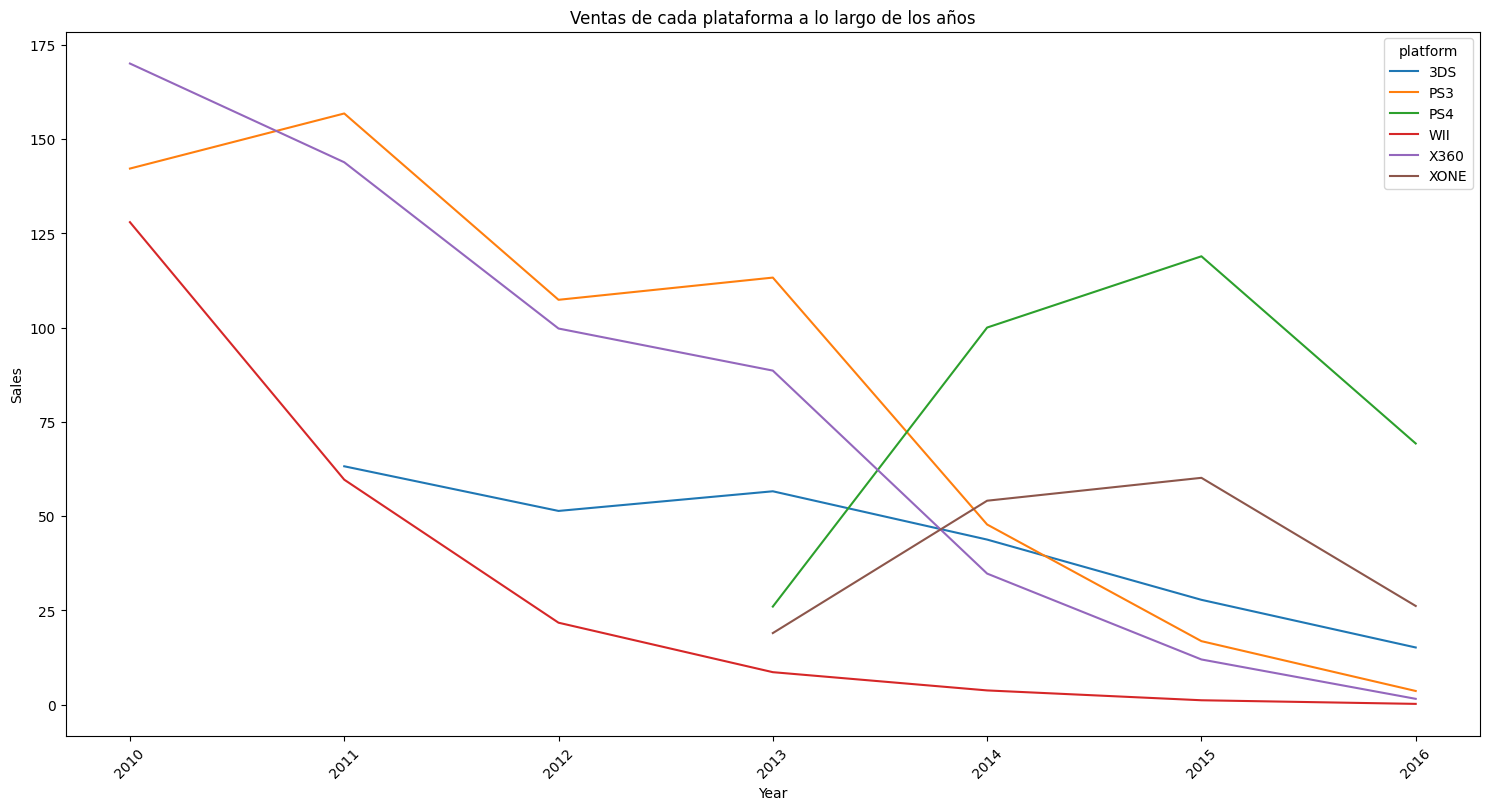

In [27]:
# Agrupamos los datos de las ventas de cada plataforma por año.
sales_per_platform_per_year = filtered_df.groupby (['platform','year_of_release'])['total_sales'].sum().reset_index()
print (sales_per_platform_per_year)

# Identificamos y graficamos las plataformas más importantes y con mayores ventas.
top_platforms = ['PS3', 'X360', 'PS4', '3DS', 'WII', 'XONE']
sales_top_platforms = sales_per_platform_per_year[sales_per_platform_per_year['platform'].isin(top_platforms)]


# Realizamos gráfico de lineas para analizar ventas a lo largo del tiempo.
plt.figure(figsize = (15,8))
sns.lineplot (data= sales_top_platforms, x='year_of_release', y= 'total_sales', hue='platform')
plt.title('Ventas de cada plataforma a lo largo de los años')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


De acuerdo con los resultados, las plataformas más relevantes en los últimos años fueron PS3, X360, PS4, 3DS, WII y XONE.
Durante los años 2010 y 2011, las plataformas con mayor popularidad fueron PS3, WII y X360; sin embargo, a partir de 2012 sus ventas cayeron considerablemente. Esto es consistente con un ciclo de vida de plataforma de aproximadamente 5-7 años. La plataforma WII es el caso más notable, ya que hacia 2016 sus ventas son prácticamente nulas, lo que sugiere que no logró adaptarse a las nuevas tendencias del mercado.
Por otro lado, 3DS ha logrado mantener ventas relativamente estables a lo largo del período analizado. En cuanto a PS4 y XONE, al ser plataformas lanzadas en 2013, aún se encuentran en proceso de maduración. Dado su crecimiento sostenido y su ciclo de vida apenas iniciado, PS4 y XONE representan las plataformas con mayor potencial para campañas publicitarias en 2017.

### 3.3 Ventas globales de los juegos.

Graficamos un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma.

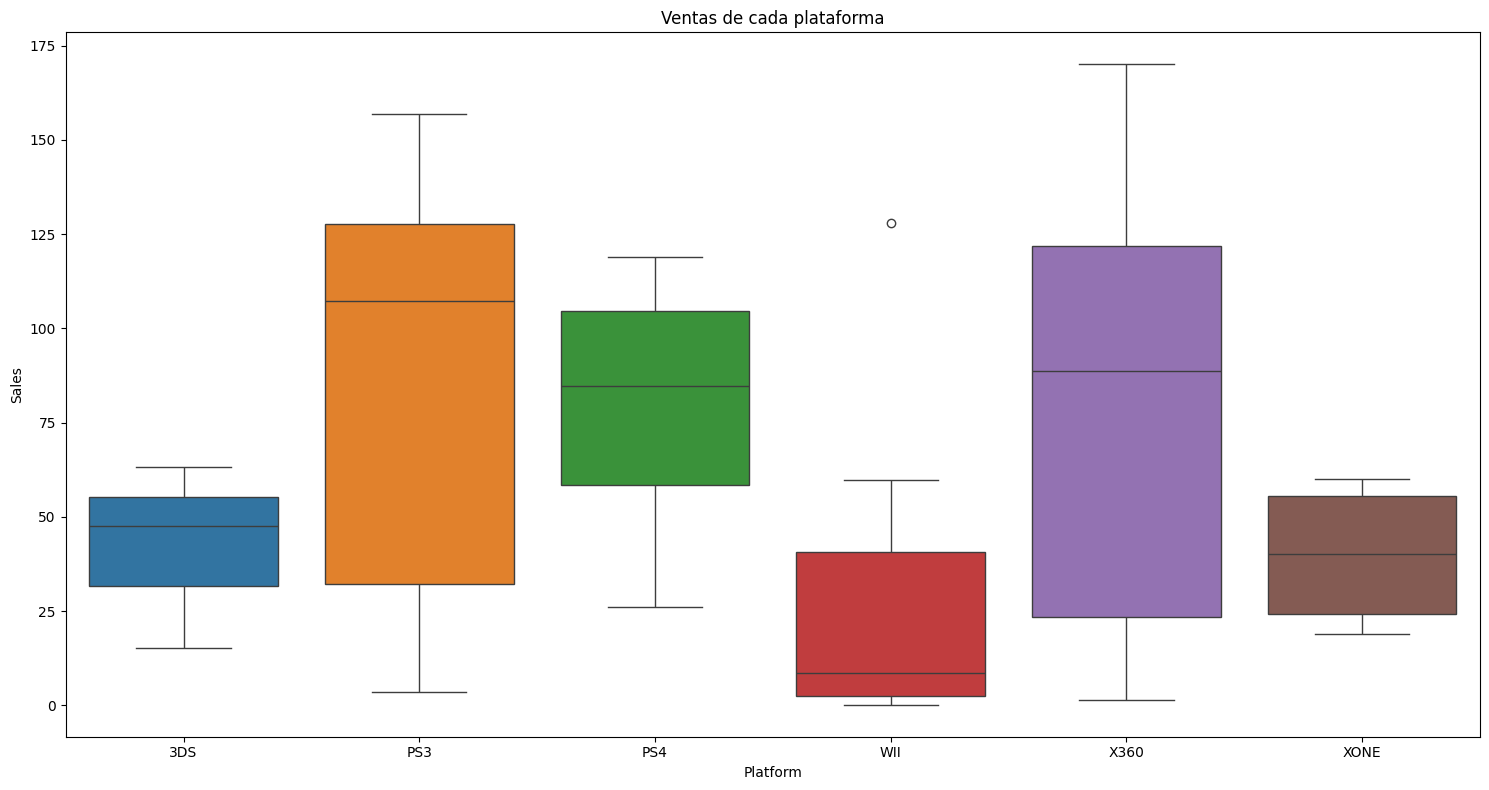

,total_sales
platform,
3DS,0.12
PS3,0.23
PS4,0.20
WII,0.18
X360,0.27
XONE,0.22


In [28]:
# Graficamos histograma.
plt.figure(figsize = (15,8))
sns.boxplot (data= sales_top_platforms, x='platform', y= 'total_sales', hue='platform')
plt.title('Ventas de cada plataforma')
plt.xlabel('Platform')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


filtered_df[filtered_df['platform'].isin(top_platforms)].groupby('platform')['total_sales'].median()

Analizando el diagrama de caja podemos ver como es que las ventas en las plataformas PS3 y X360 tienden a variar mucho entre años, por lo que son inconsistentes, pero también suelen ser ventas más riesgosas ya que pueden vender mucho o poco en cada año; sobre todo en el caso de X360 tiene un mayor rendimiento ya que tiene la mediana más alta (0.27) Por otro lado, las ventas en 3DS y XONE suelen ser más consistentes y estables. En el caso de plataformas como WII pueden ser una plataforma impredecible ya que presenta valores atipicamente altos, sin embargo sus ventas se han visto disminuidas practicamente a cero en los ultimos años.

### 3.4 Reseñas de los usuarios.

Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

En este caso usaremos la plataforma PS4 ya que se consideró que es la plataforma con mayor potencial, además de que los datos son más recientes y por lo tanto, más representativos al mercado actual, lo cual nos puede ayudar a pronosticar la campaña publicitaria.

In [29]:
# Filtramos el dataframe para unicamente quedarnos con datos de la plataforma PS4.
filtered_PS4_df = filtered_df[(filtered_df['platform'] == 'PS4')]
print(filtered_PS4_df.head())

      index                   name platform  year_of_release     genre  \
3060   4656        Just Dance 2014      PS4             2013      Misc   
3084   4917  Skylanders SWAP Force      PS4             2013  Platform   
3131    357          Battlefield 4      PS4             2013   Shooter   
3133    323   Call of Duty: Ghosts      PS4             2013   Shooter   
3198    469                FIFA 14      PS4             2013    Sports   

      na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
3060      0.19      0.16      0.00         0.07          75.0         5.5   
3084      0.20      0.12      0.00         0.06          79.0         5.2   
3131      1.35      1.55      0.17         0.51          85.0         6.9   
3133      1.78      1.43      0.05         0.57          78.0         3.7   
3198      0.61      1.85      0.11         0.44          87.0         6.3   

     rating  total_sales  
3060   E10+         0.42  
3084   E10+         0.38  
3131      M

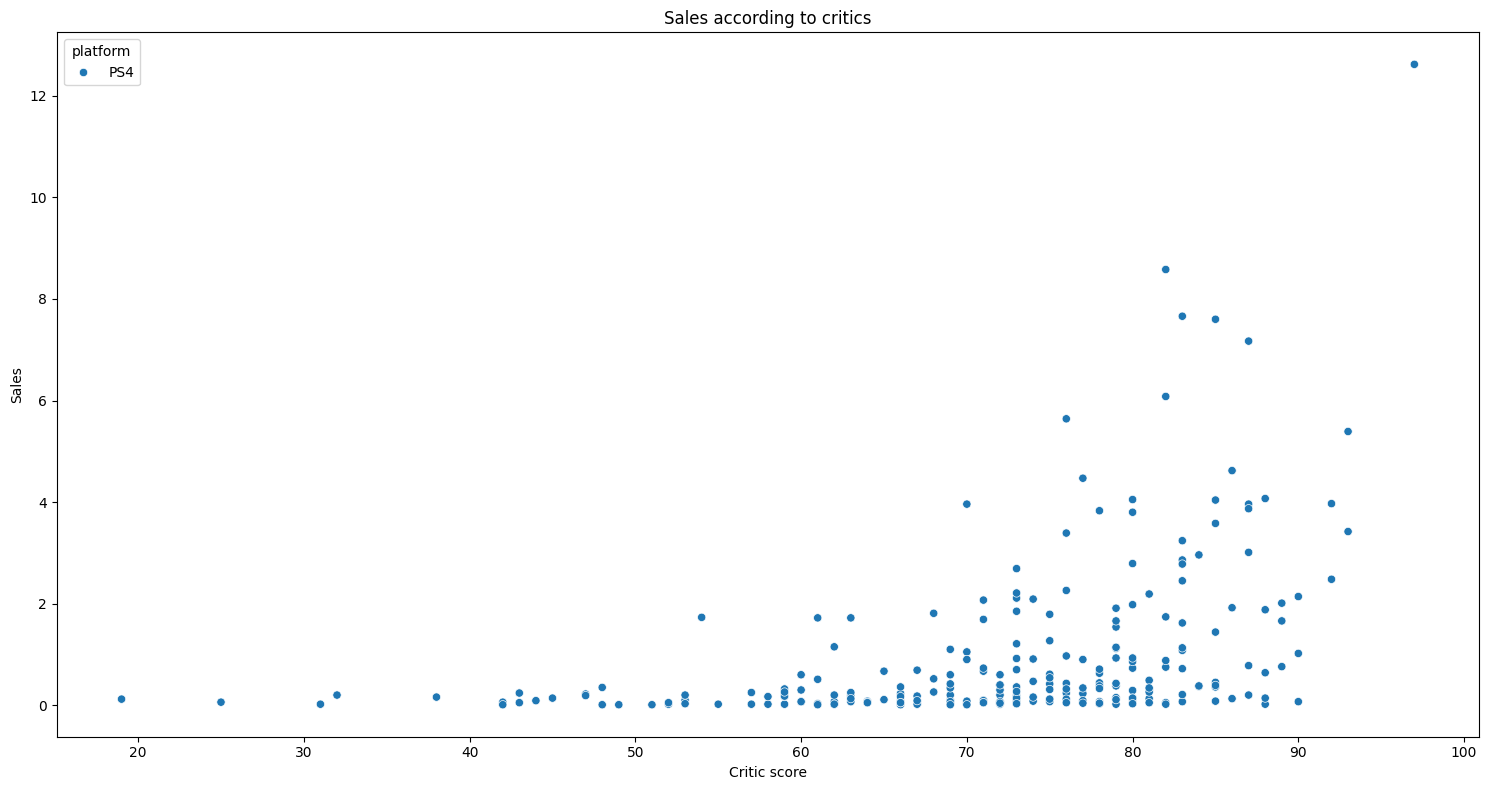

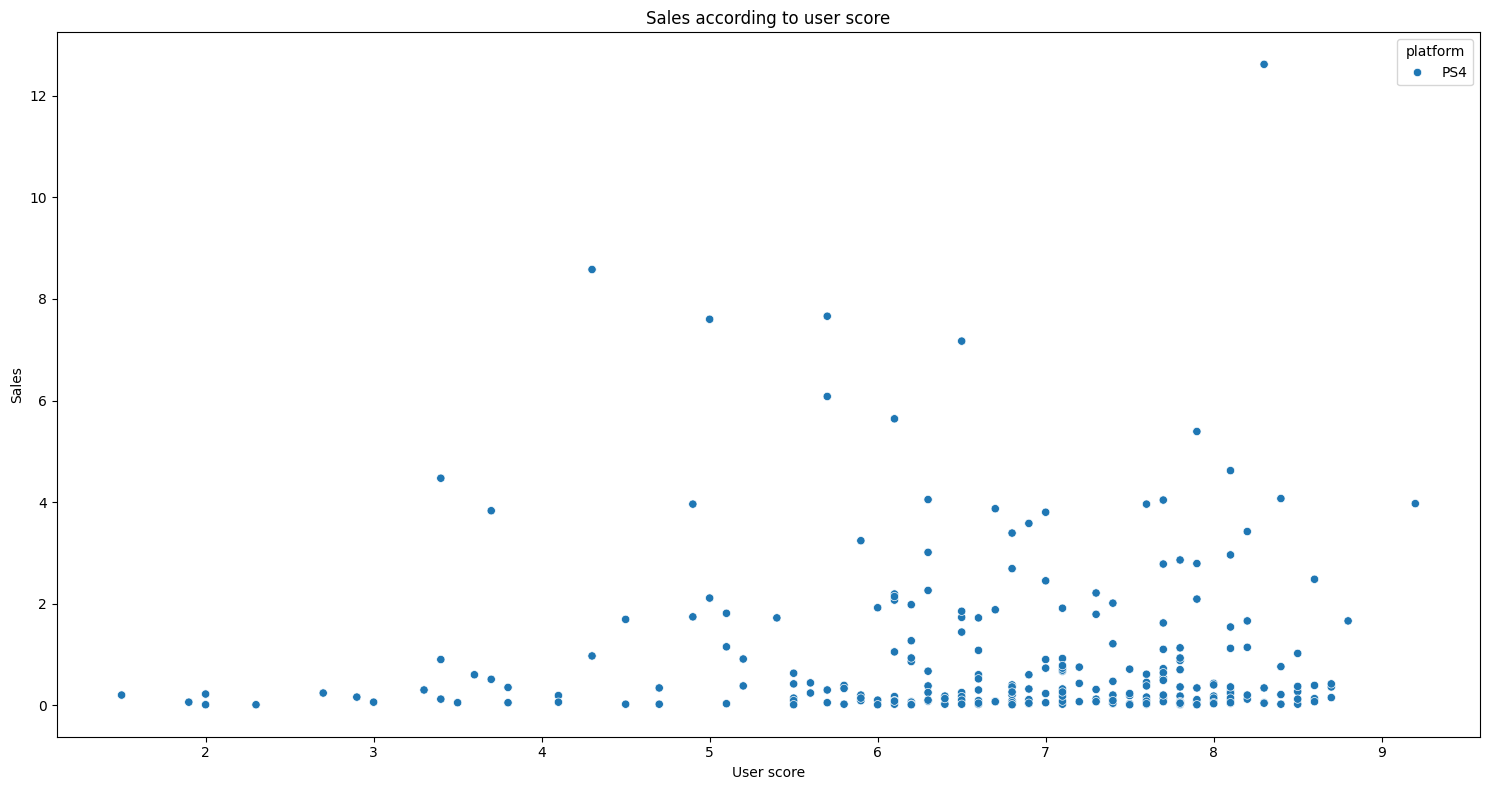


              critic_score  total_sales
critic_score      1.000000     0.406568
total_sales       0.406568     1.000000

             user_score  total_sales
user_score     1.000000    -0.031957
total_sales   -0.031957     1.000000


In [30]:
# Creacion de gráficos de dispersión:

# critic_score vs total_sales
plt.figure(figsize = (15,8))
sns.scatterplot (data= filtered_PS4_df, x='critic_score', y= 'total_sales', hue='platform')
plt.title('Sales according to critics')
plt.xlabel('Critic score')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

print ()

# user_score vs total_sales
plt.figure(figsize = (15,8))
sns.scatterplot (data= filtered_PS4_df, x='user_score', y= 'total_sales', hue='platform')
plt.title('Sales according to user score')
plt.xlabel('User score')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()
print ()

# Calculamos la correlación.
print (filtered_PS4_df[['critic_score', 'total_sales']].corr())
print ()
print (filtered_PS4_df[['user_score', 'total_sales']].corr())

Analizando los gráficos de dispersión y los coeficientes de correlación para la plataforma PS4, podemos concluir lo siguiente:
La correlación entre critic_score y total_sales (0.41) indica una correlación positiva moderada, lo que sugiere que las reseñas de los críticos tienen cierta influencia en las ventas: a mayor puntuación de los críticos, mayores ventas tienden a registrarse.
Por otro lado, la correlación entre user_score y total_sales (-0.03) es prácticamente nula, lo que indica que las reseñas de los usuarios no tienen un impacto significativo en las ventas.
Es importante señalar que estos resultados deben interpretarse con cautela, ya que ambas columnas tienen una cantidad considerable de valores ausentes, por lo que las conclusiones aplican únicamente para los juegos que sí cuentan con puntuación registrada.

## Paso 4. Perfil de usuario para cada región

Identificaremos el tipo de usuario y sus caracteristicas de consumo en cada una de sus regiones (NA, UE, JP), mediante determinar las cinco plataformas principales, géneros y como es que la clasificación de ESRB afecta a su consumo.


In [31]:
# Calculamos las ventas de cada plataforma por región

print (filtered_df.head())
print()

# Agrupamos por platafoma en NA
top_platforms_na = filtered_df.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
print ("Principales plataformas en Norteamerica:")
print (top_platforms_na.head(5))
print ()

# Agrupamos por platafoma en EU
top_platforms_eu = filtered_df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
print ("Principales plataformas en Europa:")
print (top_platforms_eu.head(5))
print()

# Agrupamos por platafoma en JP
top_platforms_jp = filtered_df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
print ("Principales plataformas en Japón:")
print (top_platforms_jp.head(5))
print()

# Agrupamos por platafoma en others
top_platforms_other = filtered_df.groupby('platform')['other_sales'].sum().sort_values(ascending=False)
print ("Principales plataformas en otras regiones:")
print (top_platforms_other.head(5))


   index                         name platform  year_of_release         genre  \
0     68                 Just Dance 2      WII             2010          Misc   
1     27  Pokemon Black/Pokemon White       DS             2010  Role-Playing   
2   4680          Tom Clancy's HAWX 2      PS3             2010        Action   
3   4669             MLB 10: The Show      PS2             2010        Sports   
4   4664    pro evolution soccer 2011      PS2             2010        Sports   

   na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0      5.80      2.85      0.01         0.78          74.0         7.3   E10+   
1      5.51      3.17      5.65         0.80           NaN         NaN    NaN   
2      0.21      0.12      0.03         0.05          70.0         6.8      T   
3      0.20      0.16      0.00         0.05           NaN         NaN      E   
4      0.04      0.21      0.05         0.11           NaN         6.7      E   

   total_sales  
0        

En Norteamérica y Europa las plataformas dominantes son muy similares, lideradas por X360 y PS3, lo que sugiere un mercado con preferencias compartidas hacia las consolas de sobremesa. Sin embargo, en Japón el panorama es completamente diferente: las plataformas predominantes son 3DS, PSP y PSV, todas portátiles. Esto refleja una preferencia cultural japonesa por la portabilidad y la movilidad en el entretenimiento, donde los dispositivos que permiten jugar en cualquier lugar tienen mayor aceptación. Cabe destacar que X360, líder en NA, prácticamente no tiene presencia en el mercado japonés.

In [32]:
# Analizamos los generos principales de cada región:

# Agrupamos por generos en NA
top_generes_na = filtered_df.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
print ("Principales generos en Norteamerica:")
print (top_generes_na.head(5))
print ()

# Agrupamos por generos en EU
top_generes_eu = filtered_df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
print ("Principales generos en Europa:")
print (top_generes_eu.head(5))
print()

# Agrupamos por generos en JP
top_generes_jp = filtered_df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
print ("Principales generos en Japón:")
print (top_generes_jp.head(5))
print()

# Agrupamos por generos en others
top_generes_other = filtered_df.groupby('genre')['other_sales'].sum().sort_values(ascending=False)
print ("Principales generos en otras regiones:")
print (top_generes_other.head(5))


Principales generos en Norteamerica:
genre
Action          290.64
Shooter         237.47
Sports          156.81
Misc            123.80
Role-Playing    112.05
Name: na_sales, dtype: float64

Principales generos en Europa:
genre
Action          233.63
Shooter         171.45
Sports          116.84
Role-Playing     75.48
Misc             66.09
Name: eu_sales, dtype: float64

Principales generos en Japón:
genre
Role-Playing    103.54
Action           72.20
Misc             24.29
Platform         15.81
Adventure        15.67
Name: jp_sales, dtype: float64

Principales generos en otras regiones:
genre
Action          76.62
Shooter         56.78
Sports          39.23
Role-Playing    24.21
Misc            20.38
Name: other_sales, dtype: float64


En Norteamérica y Europa los géneros más populares son prácticamente los mismos: Action, Shooter y Sports ocupan consistentemente el top 3. Sin embargo, Norteamérica registra un mayor volumen de ventas en todos los géneros, lo que sugiere un mercado más grande y con mayor poder adquisitivo.
Japón presenta un perfil de consumo notablemente diferente. El género Role-Playing domina claramente el mercado japonés, impulsado por franquicias icónicas de origen japonés como Final Fantasy, Pokemon y Dragon Quest, profundamente arraigadas en la cultura del anime y el manga. Por otro lado, el género Shooter, tan popular en Occidente, tiene una presencia mínima en Japón, lo que refleja diferencias culturales significativas en las preferencias de entretenimiento.

In [33]:
# Verificamos como es que la clasificación de ESRB afectan las ventas de cada region:

# Agrupamos por rating en NA
clasificacion_ESRB_na = filtered_df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
print ("Clasifiacion en Norteamerica:")
print (clasificacion_ESRB_na.head(5))
print ()

# Agrupamos por generos en EU
clasificacion_ESRB_eu = filtered_df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
print ("Clasifiacion en Europa:")
print (clasificacion_ESRB_eu.head(5))
print()

# Agrupamos por generos en JP
clasificacion_ESRB_jp = filtered_df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)
print ("Clasifiacion en Japón:")
print (clasificacion_ESRB_jp.head(5))
print()

# Agrupamos por generos en others
clasificacion_ESRB_other = filtered_df.groupby('rating')['other_sales'].sum().sort_values(ascending=False)
print ("Clasifiacion en otras regiones:")
print (clasificacion_ESRB_other.head(5))


Clasifiacion en Norteamerica:
rating
M       382.22
E       271.15
T       160.81
E10+    159.38
EC        1.13
Name: na_sales, dtype: float64

Clasifiacion en Europa:
rating
M       292.04
E       197.34
T       113.08
E10+     99.28
RP        0.03
Name: eu_sales, dtype: float64

Clasifiacion en Japón:
rating
E       47.87
T       42.11
M       30.45
E10+    13.22
EC       0.00
Name: jp_sales, dtype: float64

Clasifiacion en otras regiones:
rating
M       96.98
E       60.04
T       38.72
E10+    31.15
EC       0.07
Name: other_sales, dtype: float64


En Norteamérica y Europa la clasificación dominante es M (Mature), seguida de E (Everyone) y T (Teen). Esto sugiere que en los mercados occidentales existe una fuerte demanda de contenido para adultos, como los géneros Shooter y Action que vimos anteriormente, lo cual es consistente con los géneros predominantes en estas regiones.
En Japón, por el contrario, la clasificación E (Everyone) es la más vendida, seguida de T (Teen). La clasificación M tiene una presencia considerablemente menor. Esto es coherente con la preferencia japonesa por géneros como Role-Playing y plataformas portátiles, que suelen estar orientados a un público más amplio e intergeneracional, reflejando los valores culturales de entretenimiento familiar propios de Japón.

## Paso 5. Prueba las siguientes hipótesis:

En esta seccion buscaremos plantear las pruebas de hipotesis:


*Para formular la hipótesis nula y alternativa nos vasamos en que la hipotesis nula (H0) plantea que no hay diferencia entre los grupos de estudio mientras que para la hipotesis alternativa (H1) si podemos ver diferencias entre los grupos de estudio.*


***Establecer umbral alfa.***

Se establece un valor de alfa de 0.05 porque en el contexto de este análisis de mercado de videojuegos, estamos tomando decisiones de negocio como planificación de campañas publicitarias, donde un margen de error del 5% es aceptable y estándar en la industria.

***Prueba de hipótesis***
En este caso de estudio vamos a usar la prueba T de Student ya que
vamos a comparar medias entre dos grupos ( Xbox One vs PC), además de que tenemos datos numéricos continuos (user_score) y grupos independientes.


### 5.1 Xbox One vs PC

***Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.***


- H0 : " Las calificaciones promedio de los usuarios para Xbox One y PC son iguales"

- H1  : "Las calificaciones promedio de los usuarios para Xbox One y PC son diferentes"


In [34]:
# Filtramos los datos de cada plataforma.
XONE_df = filtered_df[filtered_df['platform']== 'XONE']
print (XONE_df.head())
print ()

PC_df =  filtered_df[filtered_df['platform']== 'PC']
print (PC_df.head())


      index                   name platform  year_of_release       genre  \
3112   5190      Zoo Tycoon (2013)     XONE             2013  Simulation   
3154   4274        Just Dance 2014     XONE             2013        Misc   
3190   5690  Skylanders SWAP Force     XONE             2013    Platform   
3215    493   Call of Duty: Ghosts     XONE             2013     Shooter   
3238    738     Forza Motorsport 5     XONE             2013      Racing   

      na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
3112      0.18      0.15      0.00         0.03           NaN         NaN   
3154      0.30      0.11      0.00         0.04          71.0         7.0   
3190      0.22      0.06      0.00         0.03           NaN         5.5   
3215      1.88      0.77      0.00         0.27          78.0         4.3   
3238      1.21      0.79      0.01         0.19          79.0         5.9   

     rating  total_sales  
3112    NaN         0.36  
3154   E10+         0.45  

In [35]:
# Realizamos prueba de hipótesis.

alpha = 0.05

results = st.ttest_ind(XONE_df['user_score'], PC_df['user_score'], nan_policy='omit')
print ('Valor p: ', results.pvalue) # Obtenemos el valor de P

if results.pvalue < alpha:
    print ("Rechazamos hipótesis nula")
else:
    print ('No rechazamos hipótesis nula')


Valor p:  0.980998110649032
No rechazamos hipótesis nula


Con un p-valor de 0.98, muy superior al umbral alfa de 0.05, no tenemos evidencia suficiente para rechazar la hipótesis nula. Por lo tanto, concluimos que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son estadísticamente iguales.

### 5.2 Acción vs Deportes

***Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.***

- H0 : " Las calificaciones promedio de los usuarios para Acción y Deportes son iguales"

- H1  : "Las calificaciones promedio de los usuarios para Acción y Deportes son diferentes"



In [36]:

# Filtramos los datos de cada plataforma.
XONE_genre_df = filtered_df[filtered_df['genre'] == 'Action']
print (XONE_genre_df.head())
print ()

PC_genre_df =  filtered_df[filtered_df['genre'] == 'Sports']
print (PC_genre_df.head())


    index                 name platform  year_of_release   genre  na_sales  \
2    4680  Tom Clancy's HAWX 2      PS3             2010  Action      0.21   
6    4640      TRON: Evolution      PS3             2010  Action      0.27   
8    4623             NBA 2K11      PSP             2010  Action      0.39   
13   4724             NBA 2K11      PS2             2010  Action      0.34   
27    125  Red Dead Redemption      PS3             2010  Action      2.79   

    eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
2       0.12      0.03         0.05          70.0         6.8      T   
6       0.09      0.00         0.05          58.0         6.2      T   
8       0.00      0.00         0.03           NaN         6.4      E   
13      0.01      0.00         0.06           NaN         NaN      E   
27      2.53      0.17         0.99          95.0         8.8      M   

    total_sales  
2          0.41  
6          0.41  
8          0.42  
13         0.41  
27      

In [37]:
# Realizamos prueba de hipótesis.

alpha = 0.05

results = st.ttest_ind(XONE_genre_df['user_score'], PC_genre_df['user_score'], nan_policy='omit')
print ('Valor p: ', results.pvalue) # Obtenemos el valor de P

if results.pvalue < alpha:
    print ("Rechazamos hipótesis nula")
else:
    print ('No rechazamos hipótesis nula')


Valor p:  7.839124224330309e-19
Rechazamos hipótesis nula


Con un p-valor de 7.839124224330309e-19, muy por debajo al umbral alfa de 0.05, podemos rechazar la hipótesis nula. Por lo tanto, concluimos que las calificaciones promedio de los usuarios para Acción y Deportes son diferentes.

## Paso 6. Conclusión general

Tras analizar el mercado de videojuegos, podemos destacar que las plataformas más prometedoras para la campaña de 2017 son PS4 y XONE, ya que su ciclo de vida aún se encuentra en crecimiento, mientras que plataformas como PS3 y X360 muestran una tendencia clara hacia el declive.
En cuanto a las preferencias regionales, Norteamérica y Europa presentan mercados similares, dominados por X360 y PS3, con preferencia por géneros como Acción, Shooter y Deportes, orientados principalmente a una audiencia adulta (clasificación M). Japón, por el contrario, muestra un perfil completamente diferente, con preferencia por plataformas portátiles como 3DS y PSP, géneros de Role-Playing y contenido apto para todos los públicos (clasificación E), lo que refleja diferencias culturales significativas respecto a los mercados occidentales.
Respecto a las reseñas, se observó que las críticas especializadas tienen una influencia moderada en las ventas (correlación 0.41), mientras que las calificaciones de los usuarios prácticamente no las afectan (correlación -0.03).
Finalmente, las pruebas de hipótesis revelaron que las calificaciones promedio de los usuarios para Xbox One y PC son estadísticamente iguales, mientras que las calificaciones entre los géneros de Acción y Deportes son estadísticamente diferentes.